## Clustering (K-Means) to discover time patterns

In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
#Load the CSV
df_2025 = pd.read_csv("moco_crime_2025.csv", low_memory=False)


In [ ]:
# Create aggregated dataset (time slots)
time_data = (
    df_2025
    .groupby(["weekday", "hour"])
    .size()
    .reset_index(name="incident_count")
)

In [8]:
time_data.head()

,weekday,hour,incident_count
0,Friday,0,369
1,Friday,1,149
2,Friday,2,110
3,Friday,3,90
4,Friday,4,70


In [ ]:
# Encode weekday (numbers instead of text)
le = LabelEncoder()
time_data["weekday_encoded"] = le.fit_transform(time_data["weekday"])

In [ ]:
# Prepare features for clustering
X = time_data[["hour", "weekday_encoded", "incident_count"]]

In [ ]:
# Scale the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
time_data["cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
# Inspect clusters
time_data.groupby("cluster")["incident_count"].mean()

cluster
0    367.0625
1    154.8000
2    168.8125
Name: incident_count, dtype: float64

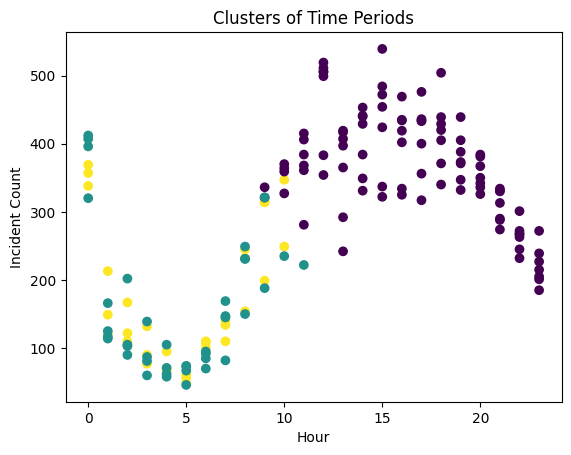

In [14]:
# visualize clusters
import matplotlib.pyplot as plt

plt.scatter(time_data["hour"], time_data["incident_count"], c=time_data["cluster"])
plt.xlabel("Hour")
plt.ylabel("Incident Count")
plt.title("Clusters of Time Periods")
plt.show()

## Supervised Learning (Classification) to predict high-incident periods

In [15]:
# Create target variable (HIGH vs NOT HIGH)
threshold = time_data["incident_count"].median()

time_data["high_activity"] = (time_data["incident_count"] > threshold).astype(int)

In [24]:
time_data_encoded = pd.get_dummies(time_data, columns=["weekday"], drop_first=True)

In [25]:
# prepare features and target
features = time_data_encoded.drop(columns=["incident_count", "high_activity", "cluster"])
target = time_data_encoded["high_activity"]



In [26]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [27]:
# train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
# make predictions
y_pred = model.predict(X_test)

In [29]:
# evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7941176470588235

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.79        16
           1       0.82      0.78      0.80        18

    accuracy                           0.79        34
   macro avg       0.79      0.80      0.79        34
weighted avg       0.80      0.79      0.79        34


Confusion Matrix:
 [[13  3]
 [ 4 14]]


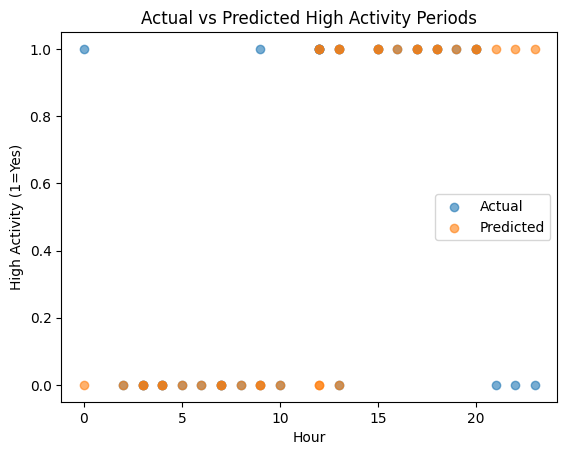

In [30]:
# SIMPLE VISUAL FOR PREDICTIONS
plt.scatter(X_test["hour"], y_test, label="Actual", alpha=0.6)
plt.scatter(X_test["hour"], y_pred, label="Predicted", alpha=0.6)
plt.legend()
plt.title("Actual vs Predicted High Activity Periods")
plt.xlabel("Hour")
plt.ylabel("High Activity (1=Yes)")
plt.show()